In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

# Better plotting style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ==========================================
# Create Dataset
# ==========================================

X, y = make_classification(
    n_samples=1200,
    n_features=12,
    n_informative=8,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

columns = [f"Feature_{i}" for i in range(1,13)]

df = pd.DataFrame(X, columns=columns)
df["Target"] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Target
0,0.058260,-1.193639,-0.831976,1.523803,-3.744025,3.383550,-1.138616,3.685562,-0.098805,-0.544494,1.415466,-1.376957,1
1,-0.892810,-4.714088,0.378002,0.928323,0.457541,1.899388,0.459291,3.086180,0.859792,2.498598,0.793877,-1.107872,1
2,-1.049757,0.807280,0.689755,-3.239486,0.300026,-0.584521,-0.404846,2.008033,5.430555,-4.262844,0.540711,-0.662600,0
3,-1.551866,-0.883982,1.327686,-1.260110,1.199783,-0.777738,-0.195328,1.839149,4.788888,-1.868965,-0.388779,1.239922,0
4,0.768624,-1.738780,1.119085,-0.960369,2.716049,-0.881300,-0.770247,3.031515,4.637318,-3.014937,0.688563,-0.903191,0


In [3]:
# Dataset Shape

print("Shape :", df.shape)

Shape : (1200, 13)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_1   1200 non-null   float64
 1   Feature_2   1200 non-null   float64
 2   Feature_3   1200 non-null   float64
 3   Feature_4   1200 non-null   float64
 4   Feature_5   1200 non-null   float64
 5   Feature_6   1200 non-null   float64
 6   Feature_7   1200 non-null   float64
 7   Feature_8   1200 non-null   float64
 8   Feature_9   1200 non-null   float64
 9   Feature_10  1200 non-null   float64
 10  Feature_11  1200 non-null   float64
 11  Feature_12  1200 non-null   float64
 12  Target      1200 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 122.0 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Feature_1,1200.0,-0.009975,1.818277,-6.239776,-1.294871,0.002984,1.217161,6.509679
Feature_2,1200.0,-0.506364,3.151928,-11.370866,-2.498419,-0.395741,1.521179,8.097111
Feature_3,1200.0,0.535317,1.918065,-6.282093,-0.664997,0.621608,1.850452,5.580492
Feature_4,1200.0,-0.564448,1.941367,-7.437326,-1.770729,-0.684506,0.705248,5.370985
Feature_5,1200.0,-0.445050,1.681428,-5.264793,-1.614521,-0.405745,0.744025,4.658798
Feature_6,1200.0,0.546272,1.672978,-6.572964,-0.505112,0.681278,1.737106,5.042074
Feature_7,1200.0,-0.026376,1.016494,-3.174749,-0.747724,-0.043853,0.669712,3.155538
Feature_8,1200.0,0.941746,1.434650,-4.808388,0.044957,0.994648,1.862538,5.217963
Feature_9,1200.0,1.928673,3.123516,-6.667137,-0.232276,1.770069,3.853798,14.326359
Feature_10,1200.0,-0.974295,1.593881,-6.876373,-2.029379,-1.015882,0.100034,3.895978


In [7]:
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Target
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,-0.009975,-0.506364,0.535317,-0.564448,-0.445050,0.546272,-0.026376,0.941746,1.928673,-0.974295,-0.029467,0.098235,0.501667
std,1.818277,3.151928,1.918065,1.941367,1.681428,1.672978,1.016494,1.434650,3.123516,1.593881,1.016014,1.751887,0.500206
min,-6.239776,-11.370866,-6.282093,-7.437326,-5.264793,-6.572964,-3.174749,-4.808388,-6.667137,-6.876373,-3.046425,-5.561696,0.000000
25%,-1.294871,-2.498419,-0.664997,-1.770729,-1.614521,-0.505112,-0.747724,0.044957,-0.232276,-2.029379,-0.722912,-1.106656,0.000000
50%,0.002984,-0.395741,0.621608,-0.684506,-0.405745,0.681278,-0.043853,0.994648,1.770069,-1.015882,-0.000195,-0.085577,1.000000
75%,1.217161,1.521179,1.850452,0.705248,0.744025,1.737106,0.669712,1.862538,3.853798,0.100034,0.657342,1.175063,1.000000
max,6.509679,8.097111,5.580492,5.370985,4.658798,5.042074,3.155538,5.217963,14.326359,3.895978,3.133537,6.335958,1.000000


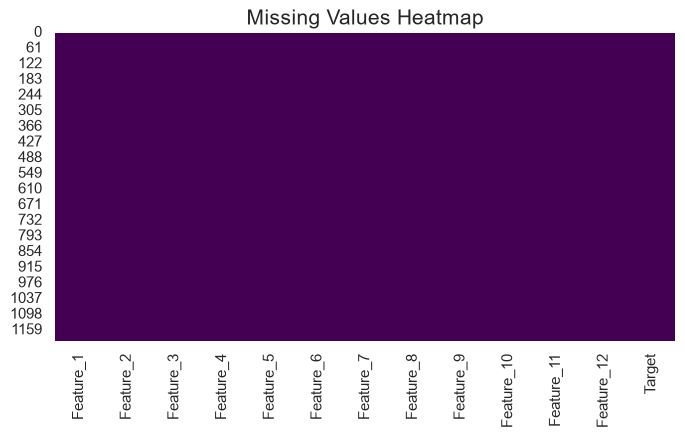

Feature_1     0
Feature_2     0
Feature_3     0
Feature_4     0
Feature_5     0
Feature_6     0
Feature_7     0
Feature_8     0
Feature_9     0
Feature_10    0
Feature_11    0
Feature_12    0
Target        0
dtype: int64


In [8]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap", fontsize=15)
plt.show()

print(df.isnull().sum())

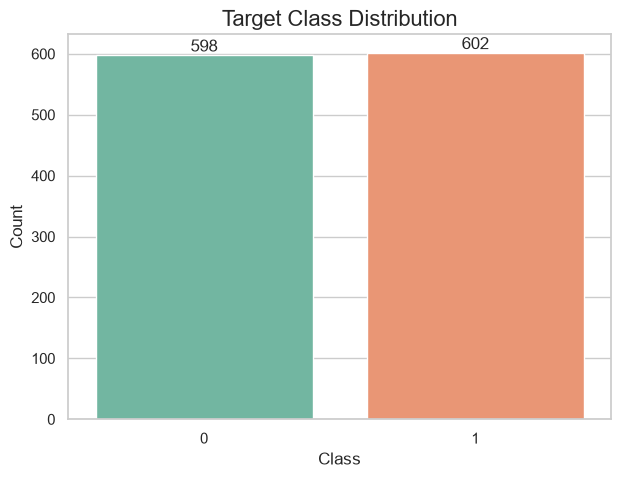

In [9]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Target",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Target Class Distribution", fontsize=16)
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

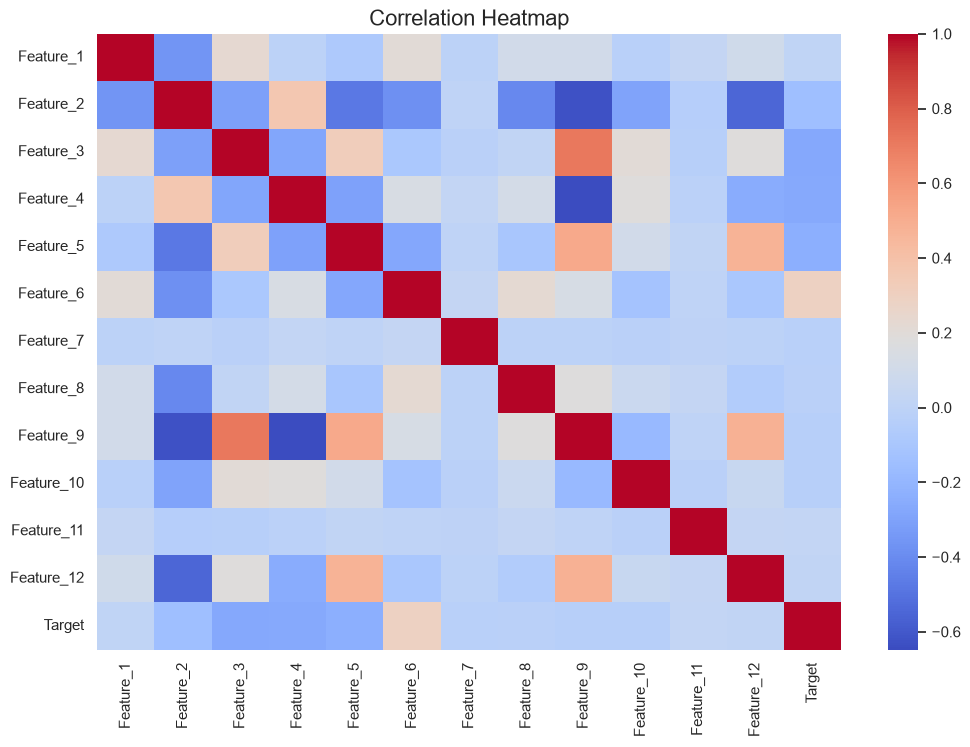

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

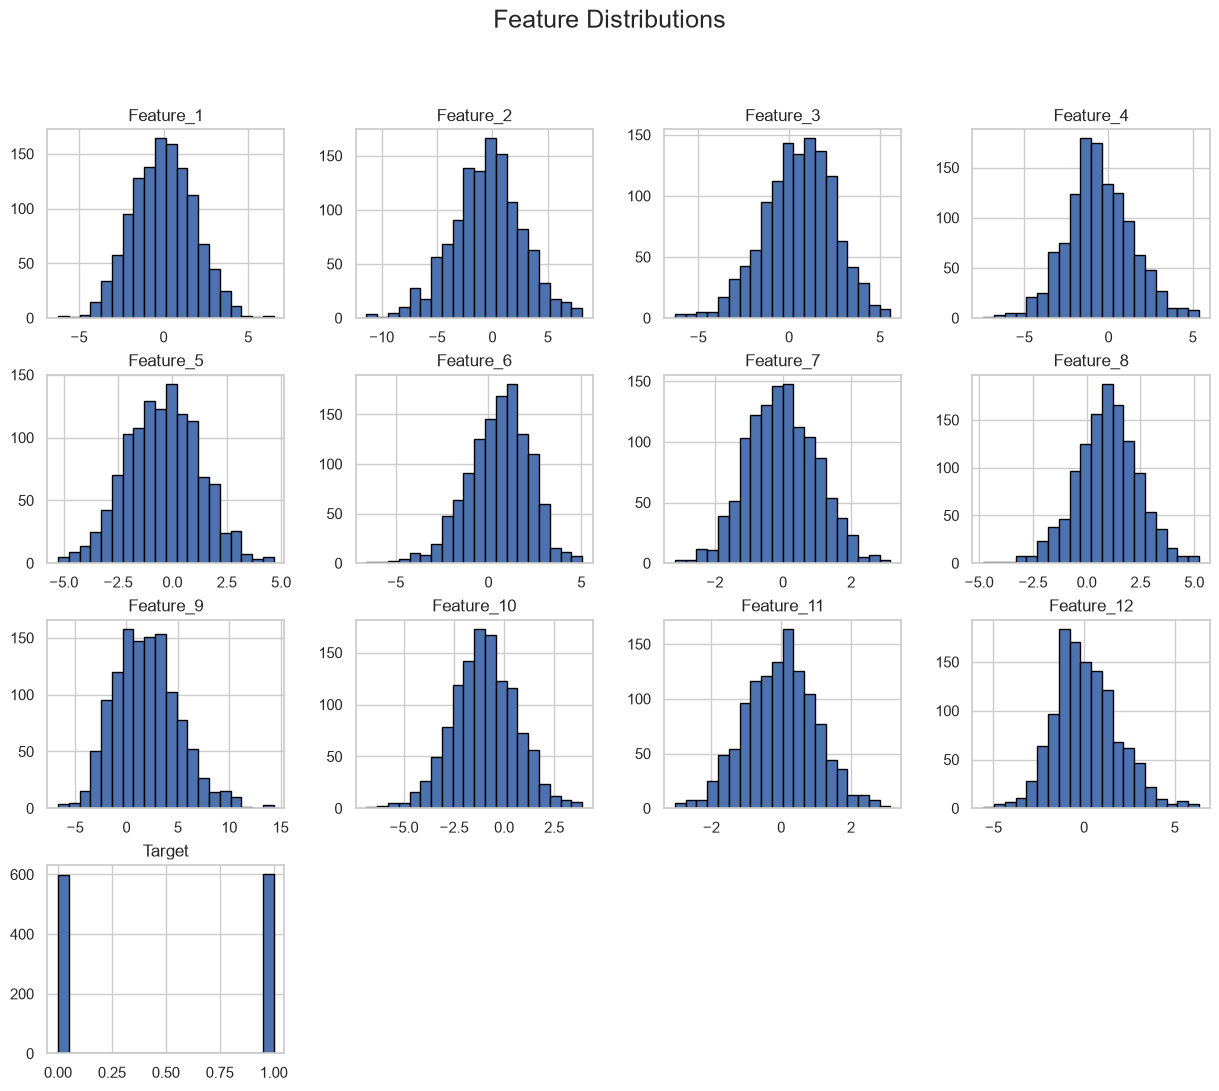

In [11]:
df.hist(
    figsize=(15,12),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Feature Distributions", fontsize=18)

plt.show()

In [12]:
X = df.drop("Target", axis=1)

y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (960, 12)
Testing Shape : (240, 12)


In [13]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", round(dt_acc*100,2),"%")

Decision Tree Accuracy : 83.33 %


In [14]:
rf = RandomForestClassifier(

    n_estimators=100,
    random_state=42,
    n_jobs=-1

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_acc*100,2),"%")

Random Forest Accuracy : 88.33 %


In [15]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        dt_acc*100,
        rf_acc*100
    ]

})

comparison

,Model,Accuracy
0,Decision Tree,83.333333
1,Random Forest,88.333333


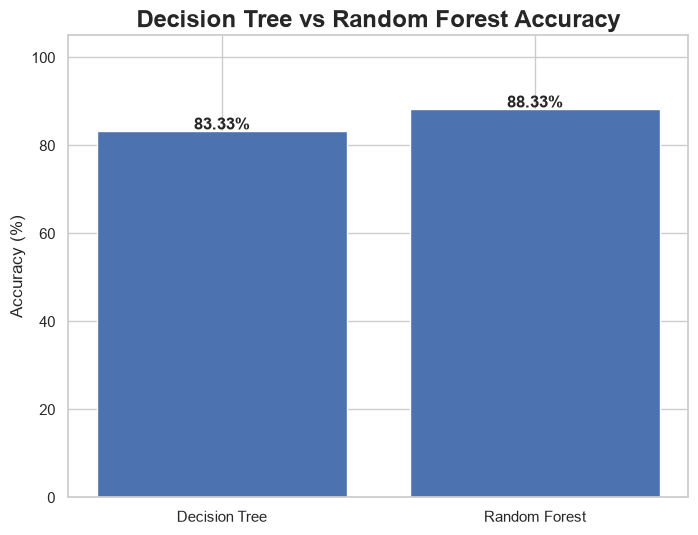

In [16]:
plt.figure(figsize=(8,6))

bars = plt.bar(

    comparison["Model"],
    comparison["Accuracy"]

)

plt.title(
    "Decision Tree vs Random Forest Accuracy",
    fontsize=17,
    weight="bold"
)

plt.ylabel("Accuracy (%)")

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x()+bar.get_width()/2,

        height+0.3,

        f"{height:.2f}%",

        ha="center",

        fontsize=12,
        weight="bold"

    )

plt.ylim(0,105)

plt.show()

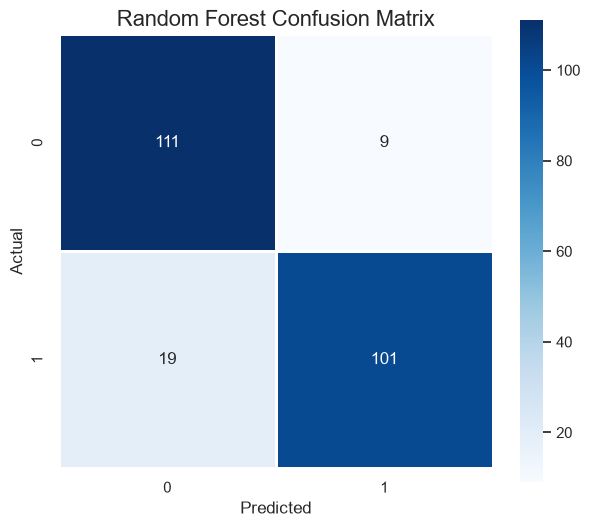

In [17]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    linewidths=2,

    square=True

)

plt.title("Random Forest Confusion Matrix", fontsize=16)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
2